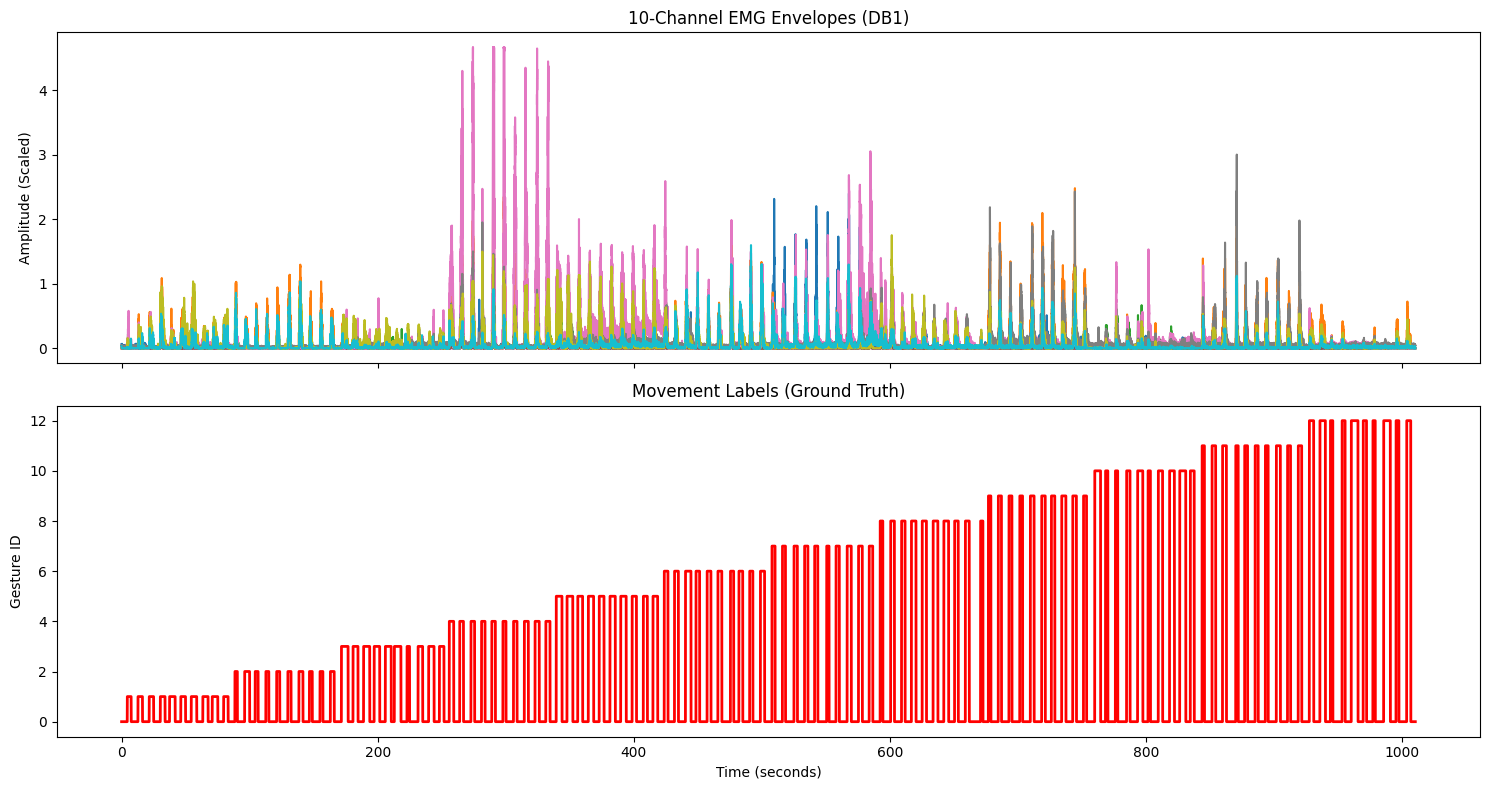

In [9]:
# Loading .mat files and visualization
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 1. Load the data
current_folder = Path.cwd()
project_root = current_folder.parent
data_path = project_root / "data" / "S1_A1_E1.mat"

data = sio.loadmat(data_path)

# 2. Extract key variables
emg = data['emg']            # The 10-channel EMG signal
labels = data['restimulus']  # The gesture IDs (0 to 52)
reps = data['repetition']    # Which repetition (1-10) it belongs to

# 3. Create a time axis (DB1 is sampled at 100Hz)
time = np.linspace(0, len(emg) / 100, len(emg))

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Plot all 10 EMG channels
ax1.plot(time, emg)
ax1.set_title('10-Channel EMG Envelopes (DB1)')
ax1.set_ylabel('Amplitude (Scaled)')

# Plot the Gesture Labels
ax2.plot(time, labels, color='red', linewidth=2)
ax2.set_title('Movement Labels (Ground Truth)')
ax2.set_ylabel('Gesture ID')
ax2.set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

In [5]:
# List of dictionary keys
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'emg', 'stimulus', 'glove', 'subject', 'exercise', 'repetition', 'restimulus', 'rerepetition'])


In [10]:
# Since you are preparing this data for an Echo State Network, normalization is critical. ESNs use non-linear activation functions (usually tanh) in the reservoir. If your input EMG values are too large, they will "saturate" the neurons (pushing them all to 1 or -1), and your reservoir will lose its ability to distinguish between different signals.
# For NinaPro DB1, the most common and effective method is Min-Max Scaling to the range [0,1].

from sklearn.preprocessing import MinMaxScaler

# 1. Identify your Training and Testing splits based on repetitions
# Example: Train on Reps 1, 3, 4, 6, 8, 9; Test on 2, 5, 7, 10
train_mask = np.isin(reps, [1, 3, 4, 6, 8, 9]).flatten()
test_mask = np.isin(reps, [2, 5, 7, 10]).flatten()

emg_train = emg[train_mask]
emg_test = emg[test_mask]

# 2. Initialize and Fit the Scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit only on training data
scaler.fit(emg_train)

# 3. Transform both sets
emg_train_norm = scaler.transform(emg_train)
emg_test_norm = scaler.transform(emg_test)

print(f"Normalized Range: {emg_train_norm.min()} to {emg_train_norm.max()}")

Normalized Range: 0.0 to 1.0000000000000002


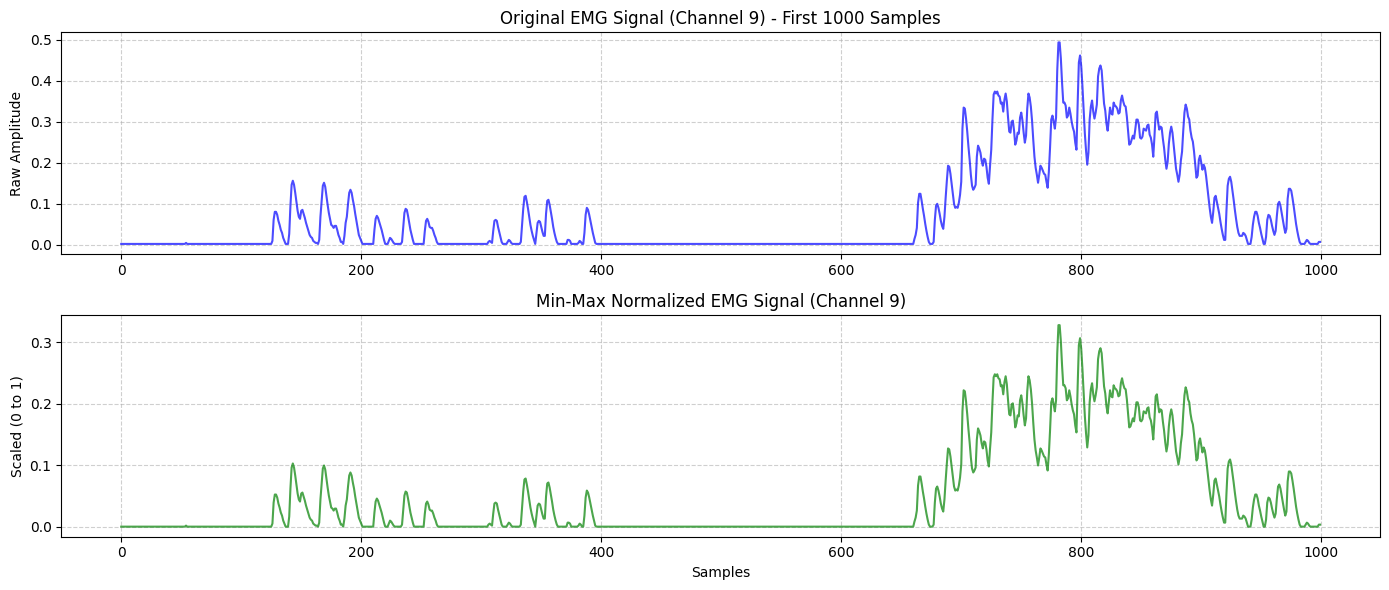

In [7]:
# Visual verification of normalization
import matplotlib.pyplot as plt

# Choose a channel to inspect (0 to 9)
channel_idx = 8 

# Create the plot
plt.figure(figsize=(14, 6))

# Plot Original Data (using the training mask segment)
plt.subplot(2, 1, 1)
plt.plot(emg_train[:1000, channel_idx], color='blue', alpha=0.7)
plt.title(f'Original EMG Signal (Channel {channel_idx+1}) - First 1000 Samples')
plt.ylabel('Raw Amplitude')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Normalized Data
plt.subplot(2, 1, 2)
plt.plot(emg_train_norm[:1000, channel_idx], color='green', alpha=0.7)
plt.title(f'Min-Max Normalized EMG Signal (Channel {channel_idx+1})')
plt.ylabel('Scaled (0 to 1)')
plt.xlabel('Samples')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [11]:
# Windowing: An ESN processes a sequence. If we just give it one sample at a time (at 100Hz, that's only 10ms of data), it's like trying to understand a word by looking at a single pixel of one letter. We need Windows to provide enough context for the reservoir to "vibrate" in a meaningful way.
#The Plan:

# Window Length (W): 20 samples (200ms). This is long enough to capture the "intent" of a muscle contraction.

# Step Size (S): 10 samples (100ms). This creates a 50% overlap, which gives us more training data and smoother transitions between gestures.
def create_windows(data, labels, window_size=20, step_size=10):
    n_samples = data.shape[0]
    n_channels = data.shape[1]
    
    windows = []
    window_labels = []
    
    for i in range(0, n_samples - window_size, step_size):
        # Extract the window
        window = data[i : i + window_size, :]
        
        # For the label, we usually take the most frequent label in that window (the Mode)
        # or simply the label at the very end of the window.
        label = labels[i + window_size - 1] 
        
        windows.append(window)
        window_labels.append(label)
        
    return np.array(windows), np.array(window_labels)

# Apply it to your data
X_train, y_train = create_windows(emg_train_norm, labels[train_mask])
X_test, y_test = create_windows(emg_test_norm, labels[test_mask])

print(f"Training shape: {X_train.shape}") 
# Expected: (Number of Windows, 20 samples, 10 channels)
# Data is now structured in a 3D tensor [Windows,Time,Features]

Training shape: (3715, 20, 10)


In [12]:
# Building the reservoir

#1. Initializing the Reservoir Parameters

#We need to define three things:

#    Input Weights (Win​): Maps your 10 EMG channels into the reservoir.

#    Reservoir Weights (Wres​): The internal connections (the "memory").

#    Spectral Radius (ρ): We must scale Wres​ so the largest eigenvalue is slightly less than 1 (e.g., 0.95). This ensures the "Echo State Property."

import numpy as np

n_inputs = 10     # 10 EMG channels
n_reservoir = 500 # Number of neurons in the "bucket"
n_outputs = 53    # 52 gestures + 1 rest label in DB1

# 1. Random Input Weights (uniform distribution between -0.1 and 0.1)
Win = (np.random.rand(n_reservoir, n_inputs) - 0.5) * 0.2

# 2. Random Reservoir Weights
Wres = np.random.rand(n_reservoir, n_reservoir) - 0.5

# 3. Scale the Reservoir for the Echo State Property
spectral_radius = np.max(np.abs(np.linalg.eigvals(Wres)))
Wres *= (0.95 / spectral_radius)

print(f"Reservoir initialized with spectral radius: {np.max(np.abs(np.linalg.eigvals(Wres)))}")

Reservoir initialized with spectral radius: 0.950000000000001


In [13]:
# Building the reservoir
#2. The State Update Function

#Now, we need to "run" each window through the reservoir. For every 20-sample window, the reservoir starts at zero and "vibrates" for 20 steps. We will keep only the final state as the feature for our classifier.
#x(t)=tanh(Win​u(t)+Wres​x(t−1))

def get_states(X_data, n_res, Win, Wres):
    n_windows = X_data.shape[0]
    window_len = X_data.shape[1]
    
    # Storage for the final state of each window
    all_states = np.zeros((n_windows, n_res))
    
    for i in range(n_windows):
        current_state = np.zeros(n_res) # Reset state for each window
        window_data = X_data[i]         # Shape (20, 10)
        
        for t in range(window_len):
            u = window_data[t]          # Input at time t
            # The core ESN math:
            current_state = np.tanh(np.dot(Win, u) + np.dot(Wres, current_state))
            
        all_states[i, :] = current_state
        
    return all_states

# Extract states for training and testing
X_train_states = get_states(X_train, n_reservoir, Win, Wres)
X_test_states = get_states(X_test, n_reservoir, Win, Wres)

print(f"Transformed features shape: {X_train_states.shape}") # (3715, 500)

# Now we have a 2D matrix (3715 x 500). The Reservoir has "digested" the 20 samples of time and turned them into a single 500-dimensional fingerprint of that movement.

Transformed features shape: (3715, 500)


In [14]:
# Training the readout
# Because X_train_states is now just a standard feature matrix, you can use a simple linear model to find the connection between the reservoir states and the labels.

from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score

# Initialize the Readout (the only part we actually train!)
readout = Ridge(alpha=1e-3) # alpha is regularization to prevent overfitting

# Fit the model
readout.fit(X_train_states, y_train)

# Predict!
y_pred = readout.predict(X_test_states)

# Since it's a regression, we round to the nearest integer for classification
y_pred_class = np.round(y_pred).astype(int)
print(f"Initial ESN Accuracy: {accuracy_score(y_test, y_pred_class) * 100:.2f}%")

# The accuracy is low, as the ESN needs more fine-tuning parameters

Initial ESN Accuracy: 11.83%


In [15]:
#1. The "Leaking Rate" (α)

#This is the most important parameter for biological signals.

#    Currently: Your neurons update instantly (xt​=tanh(…)).

#    The Fix: We introduce a "memory" factor. A small α (e.g., 0.1) makes the reservoir change slowly, perfect for smooth muscle envelopes. A large α makes it jittery.

#The Math Update:
#x(t)=(1−α)x(t−1)+αtanh(Win​u(t)+Wres​x(t−1))
#2. Input Scaling

#If your input weights Win​ are too large, the tanh function saturates (hits -1 or 1) and all your reservoir states look the same.

#    Try: Scaling your Win by a smaller factor (e.g., 0.01 instead of 0.2).

#3. The Readout: Classification vs. Regression

#Right now, you are using Ridge (linear regression). Because gesture IDs are categorical (Gesture 1 is not "half" of Gesture 2), a linear regression is trying to find a mathematical average between labels.

#    The Fix: Use Logistic Regression or a Ridge Classifier. These are designed for discrete categories.

from sklearn.linear_model import RidgeClassifier

# 1. New Hyperparameters
alpha = 0.1       # The Leaking Rate (Low = long memory)
input_scale = 0.05 # Smaller scale to avoid saturation

# 2. Re-initialize Win with smaller scale
Win = (np.random.rand(n_reservoir, n_inputs) - 0.5) * input_scale

def get_leaky_states(X_data, n_res, Win, Wres, alpha):
    n_windows, window_len, _ = X_data.shape
    all_states = np.zeros((n_windows, n_res))
    
    for i in range(n_windows):
        current_state = np.zeros(n_res)
        window_data = X_data[i]
        
        for t in range(window_len):
            u = window_data[t]
            # Leaky integration formula
            res_input = np.dot(Win, u) + np.dot(Wres, current_state)
            current_state = (1 - alpha) * current_state + alpha * np.tanh(res_input)
            
        all_states[i, :] = current_state
    return all_states

# 3. Transform again
X_train_leaky = get_leaky_states(X_train, n_reservoir, Win, Wres, alpha)
X_test_leaky = get_leaky_states(X_test, n_reservoir, Win, Wres, alpha)

# 4. Use a Classifier instead of a Regressor
classifier = RidgeClassifier(alpha=1.0)
classifier.fit(X_train_leaky, y_train.ravel())

y_pred = classifier.predict(X_test_leaky)
print(f"Improved ESN Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Improved ESN Accuracy: 54.26%


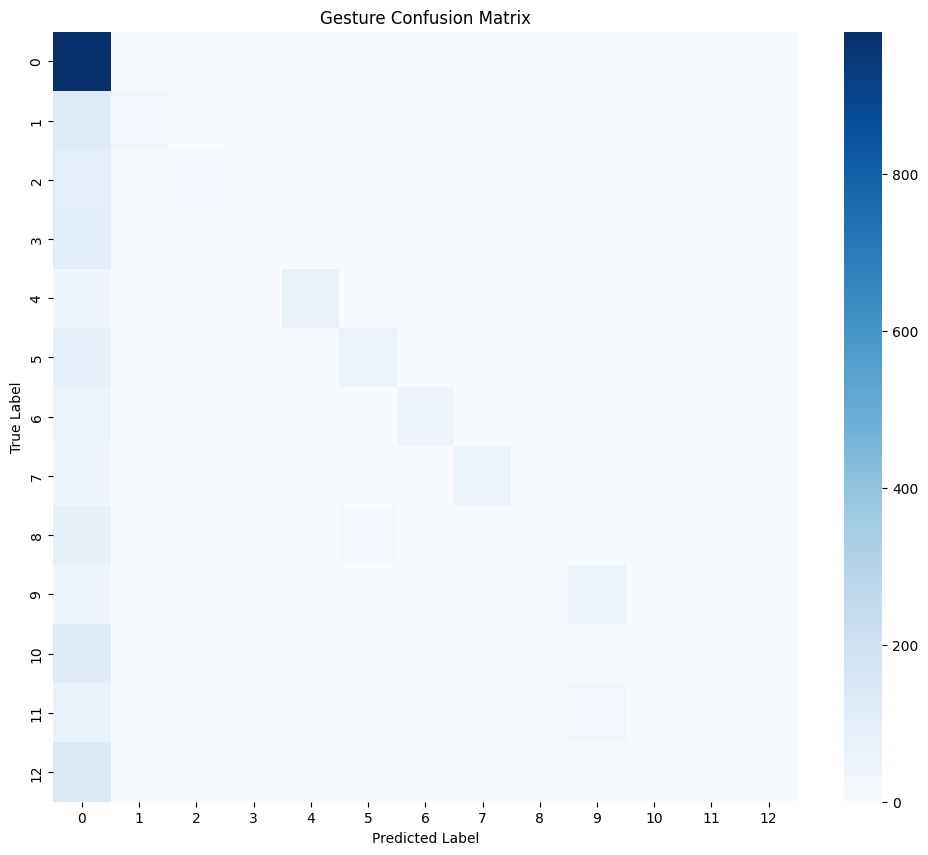

In [13]:
# Confusion matrix: diagnosis method to see if the model is conflating different gestures
# Strong Diagonal: Means the model is getting it right.
# Off-diagonal "Clusters": If you see a bright square away from the diagonal, it means the ESN is confusing two similar gestures (e.g., "Index Finger Extension" vs. "Middle Finger Extension"). 
# To fix this, you would need to increase the Spectral Radius to give the model more "fine-grained" memory.

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues')
plt.title('Gesture Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Looking at your heatmap, we can see three major "problem zones" that we need to fix to get past that 54% mark.
1. The "Rest" Bias (The first column)

Notice that tall, light-blue vertical bar on the far left (Label 0).

    The Problem: Your model is frequently predicting "Rest" (0) when the user is actually performing a movement.

    The Reason: In the NinaPro dataset, "Rest" occurs much more often than any individual gesture. Your classifier has learned that if it’s unsure, "Rest" is the safest bet to stay mathematically accurate.

    The Fix: You need to balance your classes. When training the RidgeClassifier, you can tell it to give more "weight" to the gestures:
    Python

    classifier = RidgeClassifier(alpha=1.0, class_weight='balanced')

2. The "Ghost" Gestures (Rows 10-12)

Notice how rows 10, 11, and 12 are almost completely blank on the diagonal but have blue squares in the "Rest" column.

    The Problem: The model is completely failing to recognize these specific gestures.

    The Reason: These gestures might be too subtle for a 500-node reservoir to distinguish from a relaxed arm, or the temporal "echo" isn't lasting long enough for the model to see the full movement.

3. The "Similarity Clusters"

See the little squares near labels 4-5 and 9-11?

    The Problem: The model is confusing similar movements (e.g., moving the ring finger vs. the pinky).

    The Fix: This is where Reservoir Size and Spectral Radius come in. By increasing the Spectral Radius (ρ) closer to 0.99, the reservoir's "memory" becomes more chaotic and distinct, which helps separate very similar inputs.

In [16]:
# Upgrading the ESN to a sparse reservoir
# Instead of every neuron talking to every other neuron, we will limit the connections. 
# This forces the reservoir to create "specialized pockets" of neurons, which is much better for separating 52 different gestures.

# 1. Double the size
n_reservoir = 1000 
sparsity = 0.1 # Only 10% of internal connections exist

# 2. Re-generate Win to match the new size
Win = (np.random.rand(n_reservoir, n_inputs) - 0.5) * input_scale

# 2. Create Sparse Wres
mask = np.random.rand(n_reservoir, n_reservoir) < sparsity
Wres = (np.random.rand(n_reservoir, n_reservoir) - 0.5) * mask

# 3. Re-scale Spectral Radius
spectral_radius = np.max(np.abs(np.linalg.eigvals(Wres)))
Wres *= (0.99 / spectral_radius) # Push it closer to 1.0 for longer memory

# 4. Use Balanced Ridge Classifier
classifier = RidgeClassifier(alpha=1.0, class_weight='balanced')

# 5. Transform the tensor again, using the sparse reservoir
X_train_leaky = get_leaky_states(X_train, n_reservoir, Win, Wres, alpha)
X_test_leaky = get_leaky_states(X_test, n_reservoir, Win, Wres, alpha)

# 6. Use the Balanced Ridge Classifier
classifier.fit(X_train_leaky, y_train.ravel())

# 7. Predict the gesture values with the new classifier
y_pred = classifier.predict(X_test_leaky)
print(f"Improved ESN Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Improved ESN Accuracy: 66.69%


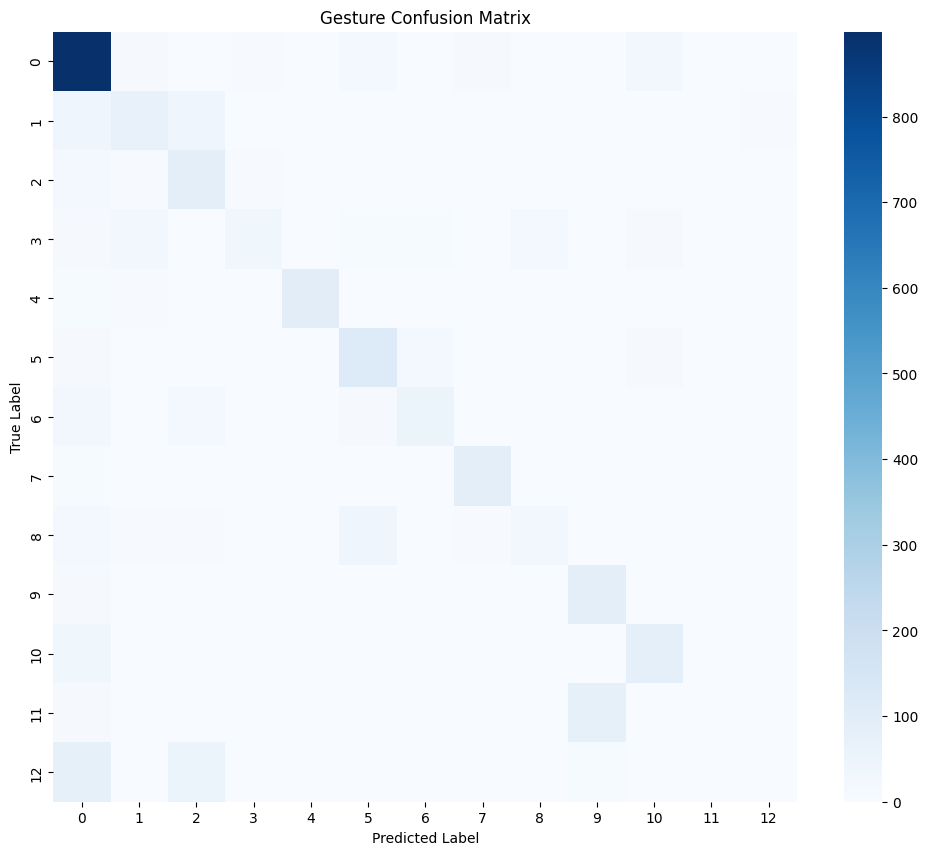

In [15]:
# Running the confusion matrix on the new model
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues')
plt.title('Gesture Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [17]:
# Hybrid feature extraction

# Right now, you are feeding the ESN raw (though normalized) EMG data. In biological signal processing, we can help the reservoir by giving it "pre-digested" mathematical features alongside the raw signal.

#The Strategy: For each 20-sample window, calculate the Mean Absolute Value (MAV) and Root Mean Square (RMS). These are the industry standards for muscle effort.
# Updated Windowing with Features:

def create_hybrid_windows(data, labels, window_size=20, step_size=10):
    n_samples, n_channels = data.shape
    windows = []
    window_labels = []
    features = [] # To store MAV/RMS
    
    for i in range(0, n_samples - window_size, step_size):
        window = data[i : i + window_size, :]
        
        # 1. Standard window for the ESN
        windows.append(window)
        
        # 2. Calculate MAV and RMS for this window (10 values each)
        mav = np.mean(np.abs(window), axis=0)
        rms = np.sqrt(np.mean(window**2, axis=0))
        
        # Combine them into a 20-feature vector
        features.append(np.concatenate([mav, rms]))
        
        window_labels.append(labels[i + window_size - 1])
        
    return np.array(windows), np.array(features), np.array(window_labels)

# Re-run windowing
X_train_raw, X_train_feat, y_train = create_hybrid_windows(emg_train_norm, labels[train_mask])
X_test_raw, X_test_feat, y_test = create_hybrid_windows(emg_test_norm, labels[test_mask])

In [18]:
# 1. Get reservoir states as you did before
X_train_states = get_leaky_states(X_train_raw, n_reservoir, Win, Wres, alpha)
X_test_states = get_leaky_states(X_test_raw, n_reservoir, Win, Wres, alpha)

# 2. CONCATENATE the manual features (MAV/RMS) to the reservoir output
X_train_combined = np.hstack([X_train_states, X_train_feat])
X_test_combined = np.hstack([X_test_states, X_test_feat])

# 3. Train the classifier on the combined 1020 features
classifier.fit(X_train_combined, y_train.ravel())
y_pred = classifier.predict(X_test_combined)

Improved ESN Accuracy: 67.90%


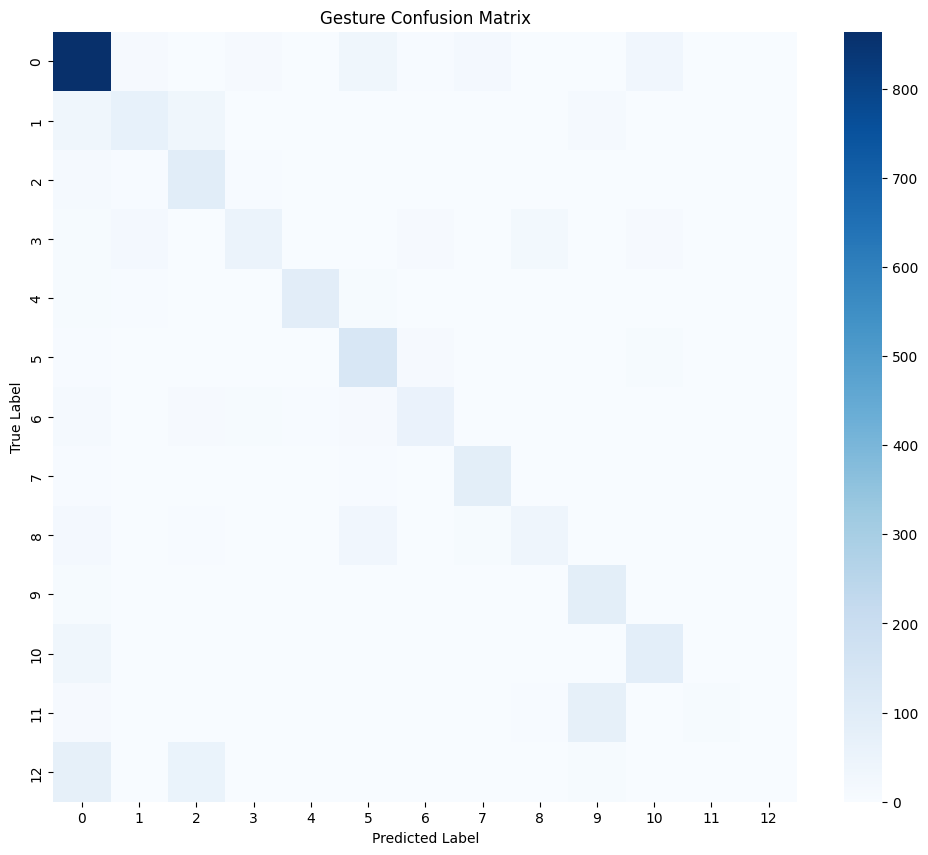

In [18]:
# Results from the hybrid feature approach
print(f"Improved ESN Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
# Running the confusion matrix on the new model
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues')
plt.title('Gesture Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [19]:
# Multi-Step Readout

# Instead of just taking the last state of the reservoir, try taking the Mean, Max, and Min of the reservoir states across the whole 20-sample window.

#     This turns your 1000-state vector into a 3000-state vector.

#    It gives the RidgeClassifier a look at the entire history of how the reservoir reacted to the window, not just where it ended up.
# This often helps when a gesture has a very specific "attack" (how it starts) or "decay" (how it ends) that gets lost if we only look at the final sample.
# We need to modify the loop to store the reservoir state at every timestep within the window, then calculate the statistics.
def get_rich_states(X_data, n_res, Win, Wres, alpha):
    n_windows, window_len, _ = X_data.shape
    # Now we store 3 statistics per neuron: Mean, Max, and Min
    all_rich_states = np.zeros((n_windows, n_res * 3))
    
    for i in range(n_windows):
        current_state = np.zeros(n_res)
        window_data = X_data[i]
        
        # To store the "history" of states for this specific window
        history = np.zeros((window_len, n_res))
        
        for t in range(window_len):
            u = window_data[t]
            res_input = np.dot(Win, u) + np.dot(Wres, current_state)
            current_state = (1 - alpha) * current_state + alpha * np.tanh(res_input)
            history[t, :] = current_state
            
        # Calculate stats across the time dimension (axis 0)
        s_mean = np.mean(history, axis=0)
        s_max  = np.max(history, axis=0)
        s_min  = np.min(history, axis=0)
        
        # Concatenate into a 3000-dimensional vector
        all_rich_states[i, :] = np.concatenate([s_mean, s_max, s_min])
        
    return all_rich_states

# Change spectral radius to 0.95
Wres = (np.random.rand(n_reservoir, n_reservoir) - 0.5) * mask
spectral_radius = np.max(np.abs(np.linalg.eigvals(Wres)))
Wres *= (0.95 / spectral_radius)

# 2. Extract the 3000-dimensional features
X_train_rich = get_rich_states(X_train_raw, n_reservoir, Win, Wres, alpha)
X_test_rich = get_rich_states(X_test_raw, n_reservoir, Win, Wres, alpha)

# 3. Combine with your MAV/RMS features (total ~3020 features)
X_train_final = np.hstack([X_train_rich, X_train_feat])
X_test_final = np.hstack([X_test_rich, X_test_feat])

# 4. Train the Balanced Classifier
classifier = RidgeClassifier(alpha=1.0, class_weight='balanced')
classifier.fit(X_train_final, y_train.ravel())

y_pred = classifier.predict(X_test_final)
print(f"Rich Feature ESN Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Rich Feature ESN Accuracy: 68.63%


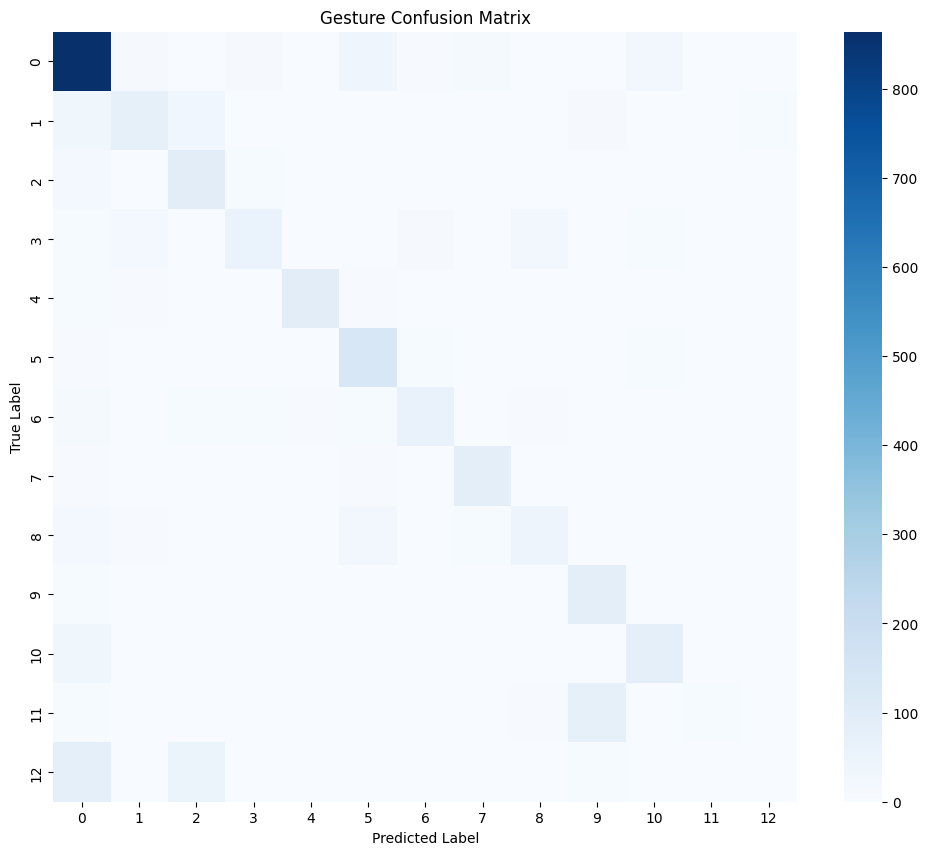

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues')
plt.title('Gesture Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Deep Echo State Networks**

In a DeepESN, the first reservoir extracts low-level temporal features (like quick spikes), and the second reservoir processes those features to find higher-level patterns (like the overall "shape" of the gesture).

This hierarchy often provides a much better "memory" than just making a single reservoir larger.
1. The Architecture of a DeepESN

Instead of the input u(t) going to all 1000 neurons, it only goes to Layer 1.

    Layer 1 generates a state x1​(t).

    Layer 2 uses x1​(t) as its "input" to generate state x2​(t).

    Your Readout (the Classifier) looks at the states of all layers combined.

In [20]:
# Hyperparameters for DeepESN
n_layers = 2
n_res_per_layer = 500
n_inputs = 10
alpha_l1 = 0.2      # We can use different leak rates per layer!
alpha_l2 = 0.05
input_scale = 0.1

# 1. Initialize Weights for each layer
# Win only connects to the first layer
Win = (np.random.rand(n_res_per_layer, n_inputs) - 0.5) * input_scale

# Internal reservoir weights and inter-layer weights
Wres_list = []
Winter_list = [] # Connections between Layer 1 -> Layer 2

for i in range(n_layers):
    # Internal Reservoir (Sparse)
    mask = np.random.rand(n_res_per_layer, n_res_per_layer) < 0.1
    W = (np.random.rand(n_res_per_layer, n_res_per_layer) - 0.5) * mask
    
    # Scale Spectral Radius for stability
    sr = np.max(np.abs(np.linalg.eigvals(W)))
    W *= (0.95 / sr)
    Wres_list.append(W)
    
    # Connection from Layer (i) to Layer (i+1)
    if i < n_layers - 1:
        W_inter = (np.random.rand(n_res_per_layer, n_res_per_layer) - 0.5) * 0.1
        Winter_list.append(W_inter)

In [21]:
# Deep state update
# The math changes slightly: each layer's state at time t depends on its own previous state and the current state of the layer below it.
def get_rich_deep_states(X_data, n_layers, n_res, Win, Wres_list, Winter_list, alpha_l1, alpha_l2):
    n_windows, window_len, _ = X_data.shape
    
    # CRITICAL: We use n_res (which is 500) here
    all_features = np.zeros((n_windows, n_layers * n_res * 3))
    
    for i in range(n_windows):
        # Initialize each layer with the correct layer size (500)
        states = [np.zeros(n_res) for _ in range(n_layers)]
        window_data = X_data[i]
        
        # Track history for all layers: Shape (window_len, n_layers, n_res)
        history = np.zeros((window_len, n_layers, n_res))
        
        for t in range(window_len):
            u = window_data[t]
            
            # Layer 1 Update
            l1_input = np.dot(Win, u) + np.dot(Wres_list[0], states[0])
            states[0] = (1 - alpha_l1) * states[0] + alpha_l1 * np.tanh(l1_input)
            history[t, 0, :] = states[0]
            
            # Subsequent Layers Update
            for L in range(1, n_layers):
                l_input = np.dot(Winter_list[L-1], states[L-1]) + np.dot(Wres_list[L], states[L])
                states[L] = (1 - alpha_l2) * states[L] + alpha_l2 * np.tanh(l_input)
                history[t, L, :] = states[L]
        
        # Flatten the history for statistics
        layer_stats = []
        for L in range(n_layers):
            layer_history = history[:, L, :] # Shape (20, 500)
            layer_stats.append(np.mean(layer_history, axis=0))
            layer_stats.append(np.max(layer_history, axis=0))
            layer_stats.append(np.min(layer_history, axis=0))
            
        all_features[i, :] = np.concatenate(layer_stats)
        
    return all_features

In [22]:
# Double check sizes before running
#print(f"Win shape: {Win.shape}") # Should be (500, 10)
#print(f"Wres[0] shape: {Wres_list[0].shape}") # Should be (500, 500)

# Execute
X_train_ultimate = get_rich_deep_states(X_train_raw, 2, 500, Win, Wres_list, Winter_list, alpha_l1, alpha_l2)
X_test_ultimate = get_rich_deep_states(X_test_raw, 2, 500, Win, Wres_list, Winter_list, alpha_l1, alpha_l2)

# Append MAV/RMS (optional but recommended)
X_train_final = np.hstack([X_train_ultimate, X_train_feat])
X_test_final = np.hstack([X_test_ultimate, X_test_feat])

classifier = RidgeClassifier(alpha=0.01, class_weight='balanced') # Changing the value of alpha can prevent overfitting on training data
classifier.fit(X_train_final, y_train.ravel())
print(f"Final Deep-Rich Accuracy: {classifier.score(X_test_final, y_test.ravel())*100:.2f}%")

Final Deep-Rich Accuracy: 72.75%


RidgeClassifier alpha = 0 -> Final Deep-Rich Accuracy: 32.14%
RidgeClassifier alpha = 0.001 -> Final Deep-Rich Accuracy: 71.42%
RidgeClassifier alpha = 0.01 -> Final Deep-Rich Accuracy: 72.02%
RidgeClassifier alpha = 0.05 -> Final Deep-Rich Accuracy: 71.82%
RidgeClassifier alpha = 0.1 -> Final Deep-Rich Accuracy: 70.81%
RidgeClassifier alpha = 0.2 -> Final Deep-Rich Accuracy: 70.37%
RidgeClassifier alpha = 10 -> Final Deep-Rich Accuracy: 67.62%
RidgeClassifier alpha = 50 -> Final Deep-Rich Accuracy: 66.29%

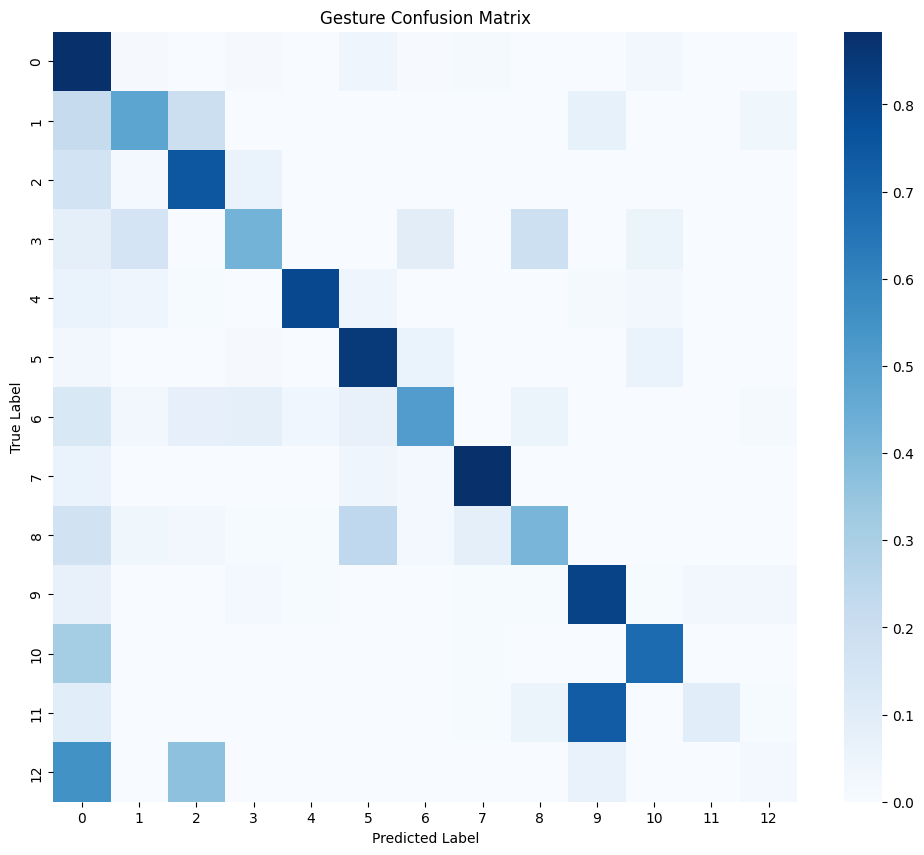

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
# Normalization (to see percentages instead of raw window counts)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized,annot=False, cmap='Blues', fmt='.2f')
plt.title('Gesture Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [24]:
# The "Majority Vote" Filter (The Final Polish)
# We apply a Temporal Smoothing Filter
# Because you are using overlapping windows, your model might predict:
# [Gesture 5, Gesture 5, Rest, Gesture 5, Gesture 5]
# That "Rest" in the middle is almost certainly a glitch. Human muscles don't relax and contract again in 100ms.

from scipy import stats

def majority_vote_filter(predictions, window_size=5):
    smoothed = np.copy(predictions)
    for i in range(window_size, len(predictions) - window_size):
        # Look at a local neighborhood of predictions
        neighborhood = predictions[i - window_size : i + window_size + 1]
        # Replace current prediction with the most frequent one in the neighborhood
        smoothed[i] = stats.mode(neighborhood)[0]
    return smoothed

# Apply to your best y_pred (from alpha=0.01)
y_pred_smooth = majority_vote_filter(y_pred, window_size=3)
print(f"Smoothed Accuracy: {accuracy_score(y_test, y_pred_smooth) * 100:.2f}%")

Smoothed Accuracy: 69.56%
